In [1]:
import sys
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import models

sys.path.append(str(Path.cwd().parent))

from src.data_pipeline import build_dataloaders

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [3]:
RAW_DIR = "../data/raw/chest_xray"

loaders = build_dataloaders(
    raw_dir=RAW_DIR,
    batch_size=32,
    val_size=0.15,
    num_workers=2
)

train_loader = loaders.train
val_loader = loaders.val
test_loader = loaders.test

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 139
Validation batches: 25
Test batches: 20


In [4]:
weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\HARDIK/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:06<00:00, 3.53MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [5]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [6]:
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [7]:
for param in model.features.parameters():
    param.requires_grad = False

In [8]:
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print("Trainable parameters:", trainable)
print("Total parameters:", total)

Trainable parameters: 2562
Total parameters: 4010110


In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    loss = running_loss / len(loader)
    accuracy = correct / total

    return loss, accuracy

In [11]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    loss = running_loss / len(loader)
    accuracy = correct / total

    return loss, accuracy

In [12]:
EPOCHS = 10

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/10 | Train Loss: 0.2969 | Train Acc: 0.8788 | Val Loss: 0.2638 | Val Acc: 0.8764
Epoch 2/10 | Train Loss: 0.2055 | Train Acc: 0.9224 | Val Loss: 0.2988 | Val Acc: 0.8739
Epoch 3/10 | Train Loss: 0.1856 | Train Acc: 0.9310 | Val Loss: 0.2750 | Val Acc: 0.8841
Epoch 4/10 | Train Loss: 0.1673 | Train Acc: 0.9325 | Val Loss: 0.2190 | Val Acc: 0.9070
Epoch 5/10 | Train Loss: 0.1752 | Train Acc: 0.9323 | Val Loss: 0.1838 | Val Acc: 0.9197
Epoch 6/10 | Train Loss: 0.1683 | Train Acc: 0.9341 | Val Loss: 0.2432 | Val Acc: 0.8981
Epoch 7/10 | Train Loss: 0.1567 | Train Acc: 0.9386 | Val Loss: 0.2244 | Val Acc: 0.9134
Epoch 8/10 | Train Loss: 0.1601 | Train Acc: 0.9382 | Val Loss: 0.2668 | Val Acc: 0.8930
Epoch 9/10 | Train Loss: 0.1636 | Train Acc: 0.9310 | Val Loss: 0.1689 | Val Acc: 0.9299
Epoch 10/10 | Train Loss: 0.1566 | Train Acc: 0.9375 | Val Loss: 0.1646 | Val Acc: 0.9350


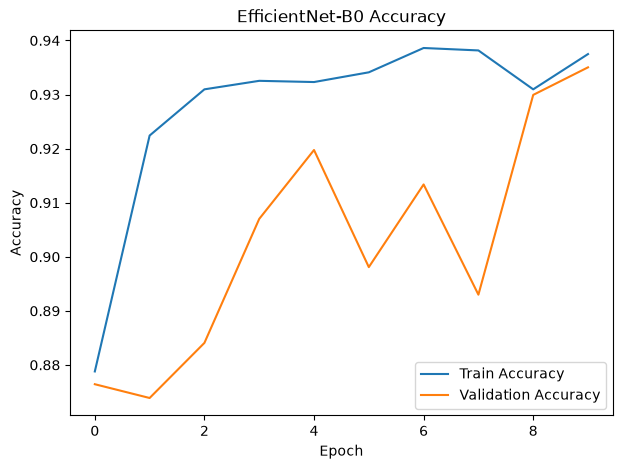

In [13]:
plt.figure(figsize=(7, 5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B0 Accuracy")

plt.legend()
plt.show()

In [14]:
Path("../models").mkdir(exist_ok=True)

torch.save(
    model.state_dict(),
    "../models/efficientnet_b0_transfer.pth"
)

print("EfficientNet-B0 model saved.")

EfficientNet-B0 model saved.
